# Project 1: Credit Risk Scorecard
## Notebook 2: Scorecard Model

### Context
This notebook picks up from the EDA in Notebook 1. We start with 28 features selected by Information Value filtering, multicollinearity removal, and fair lending exclusions. The goal is to build a production-grade credit scorecard using logistic regression.

### Why Logistic Regression?
Regulated lenders (banks, NBFCs, fintechs under RBI or ECOA guidelines) require models that are fully interpretable, auditable, and monotonic. Logistic regression satisfies all three. XGBoost may score higher on AUC, but it cannot explain a decline decision to a regulator in plain English. In credit risk, interpretability is not optional, it is a compliance requirement.

### Notebook Objectives
1. WOE-transform selected features for model input
2. Train logistic regression with L2 regularization
3. Evaluate with AUC-ROC, Gini coefficient, KS statistic, and precision-recall curve
4. Convert model probabilities to a points-based scorecard (300 to 900 scale)
5. Calculate SHAP values for global and local explainability
6. Save the trained model and scorecard mapping for API use in Notebook 3

## 1. Setup and Configuration

In [1]:
%pip install optbinning

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import warnings
import random
import os
import shap
import joblib
import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from optbinning import BinningProcess
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_PATH = '../Data/Processed/application_final_features.csv'

print("notebook run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


notebook run: 2026-08-28 12:03


In [3]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


## 2.Load Data

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Numeric features: {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical features: {df.select_dtypes(include='object').shape[1]}")
print(f"\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())
df.head()

Shape: (307511, 42)
Memory usage: 218.6 MB
Numeric features: 34
Categorical features: 8

Categorical columns:
['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'HOUSETYPE_MODE', 'NAME_FAMILY_STATUS']


,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,YEARS_EMPLOYED,AGE_YEARS,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,DAYS_LAST_PHONE_CHANGE,AMT_CREDIT,FLOORSMAX_AVG,DAYS_ID_PUBLISH,TOTALAREA_MODE,REGION_POPULATION_RELATIVE,LIVINGAREA_AVG,APARTMENTS_AVG,ELEVATORS_MEDI,ELEVATORS_MODE,REGION_RATING_CLIENT_W_CITY,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MODE,ENTRANCES_AVG,ENTRANCES_MEDI,WALLSMATERIAL_MODE,DAYS_REGISTRATION,ENTRANCES_MODE,AMT_ANNUITY,EMERGENCYSTATE_MODE,OWN_CAR_AGE,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,NONLIVINGAREA_MODE,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,NAME_FAMILY_STATUS,BASEMENTAREA_MODE,FLOORSMIN_AVG,TARGET,SK_ID_CURR
0,0.139,0.263,0.083,1.745,25.921,Laborers,Business Entity Type 3,Working,Secondary / secondary special,-1134.000,406597.500,0.083,-2120,0.015,0.019,0.019,0.025,0.000,0.000,2,0.972,0.972,0.972,0.069,0.069,"Stone, brick",-3648.000,0.069,24700.500,No,NaN,0.000,0.000,block of flats,0.000,0.037,0.037,Single / not married,0.038,0.125,1,100002
1,NaN,0.622,0.311,3.255,45.932,Core staff,School,State servant,Higher education,-828.000,1293502.500,0.292,-291,0.071,0.004,0.055,0.096,0.080,0.081,1,0.985,0.985,0.985,0.035,0.035,Block,-1186.000,0.035,35698.500,No,NaN,0.010,0.010,block of flats,0.000,0.053,0.053,Married,0.054,0.333,0,100003
2,0.730,0.556,NaN,0.616,52.181,Laborers,Government,Working,Secondary / secondary special,-815.000,135000.000,NaN,-2531,NaN,0.010,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,-4260.000,NaN,6750.000,NaN,26.000,NaN,NaN,NaN,NaN,NaN,NaN,Single / not married,NaN,NaN,0,100004
3,NaN,0.650,NaN,8.326,52.068,Laborers,Business Entity Type 3,Working,Secondary / secondary special,-617.000,312682.500,NaN,-2437,NaN,0.008,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,-9833.000,NaN,29686.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Civil marriage,NaN,NaN,0,100006
4,NaN,0.323,NaN,8.323,54.608,Core staff,Religion,Working,Secondary / secondary special,-1106.000,513000.000,NaN,-3458,NaN,0.029,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,-4311.000,NaN,21865.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single / not married,NaN,NaN,0,100007


## 3. Spliting the data

In [5]:
X = df.drop(columns = ['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify = y, random_state = RANDOM_STATE)

print(X_train.shape, X_test.shape, y_test.shape, y_train.shape)

(246008, 40) (61503, 40) (61503,) (246008,)


In [6]:
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")

Train default rate: 0.0807
Test default rate:  0.0807


In [7]:
missing_pct = (X_train.isnull().sum()/len(X_train)) *100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending = False)
print(missing_pct)

FLOORSMIN_AVG                  67.852
OWN_CAR_AGE                    66.021
BASEMENTAREA_AVG               58.465
BASEMENTAREA_MODE              58.465
BASEMENTAREA_MEDI              58.465
EXT_SOURCE_1                   56.338
NONLIVINGAREA_MEDI             55.130
NONLIVINGAREA_MODE             55.130
NONLIVINGAREA_AVG              55.130
ELEVATORS_MODE                 53.257
ELEVATORS_MEDI                 53.257
WALLSMATERIAL_MODE             50.801
APARTMENTS_AVG                 50.702
ENTRANCES_MEDI                 50.313
ENTRANCES_AVG                  50.313
ENTRANCES_MODE                 50.313
LIVINGAREA_AVG                 50.186
HOUSETYPE_MODE                 50.132
FLOORSMAX_AVG                  49.713
YEARS_BEGINEXPLUATATION_MODE   48.758
YEARS_BEGINEXPLUATATION_MEDI   48.758
YEARS_BEGINEXPLUATATION_AVG    48.758
TOTALAREA_MODE                 48.253
EMERGENCYSTATE_MODE            47.389
OCCUPATION_TYPE                31.275
EXT_SOURCE_3                   19.839
YEARS_EMPLOY

In [8]:
iv_df = pd.read_csv('../Data/Processed/iv_values.csv')
print(iv_df)

              feature    IV
0        EXT_SOURCE_3 0.329
1        EXT_SOURCE_2 0.306
2        EXT_SOURCE_1 0.151
3       DAYS_EMPLOYED 0.111
4      YEARS_EMPLOYED 0.111
..                ...   ...
120  FLAG_DOCUMENT_21 0.000
121  FLAG_DOCUMENT_17 0.000
122  FLAG_DOCUMENT_18 0.000
123  FLAG_DOCUMENT_19 0.000
124  FLAG_DOCUMENT_20 0.000

[125 rows x 2 columns]


In [9]:
iv_df = iv_df[iv_df['feature'].isin(X_train.columns)]
print(f"IV values for {len(iv_df)} selected features")
print(iv_df.to_string(index = False))

IV values for 40 selected features
                     feature    IV
                EXT_SOURCE_3 0.329
                EXT_SOURCE_2 0.306
                EXT_SOURCE_1 0.151
              YEARS_EMPLOYED 0.111
                   AGE_YEARS 0.084
             OCCUPATION_TYPE 0.083
           ORGANIZATION_TYPE 0.073
            NAME_INCOME_TYPE 0.058
         NAME_EDUCATION_TYPE 0.051
      DAYS_LAST_PHONE_CHANGE 0.047
                  AMT_CREDIT 0.045
               FLOORSMAX_AVG 0.038
             DAYS_ID_PUBLISH 0.038
              TOTALAREA_MODE 0.036
  REGION_POPULATION_RELATIVE 0.035
              LIVINGAREA_AVG 0.034
              APARTMENTS_AVG 0.032
              ELEVATORS_MEDI 0.031
              ELEVATORS_MODE 0.030
 REGION_RATING_CLIENT_W_CITY 0.029
YEARS_BEGINEXPLUATATION_MEDI 0.029
 YEARS_BEGINEXPLUATATION_AVG 0.029
YEARS_BEGINEXPLUATATION_MODE 0.029
               ENTRANCES_AVG 0.028
              ENTRANCES_MEDI 0.028
          WALLSMATERIAL_MODE 0.027
           DAYS_REGI

In [10]:
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100

drop_candidates = []
keep_despite_missing = []

for col in X_train.columns:
    miss = missing_pct[col]
    iv = iv_df[iv_df['feature'] == col]['IV'].values[0]

    if miss > 45 and iv < 0.05:
        drop_candidates.append({'feature': col, 'missing_pct': round(miss, 1), 'IV': iv})
    elif miss > 45 and iv >= 0.05:
        keep_despite_missing.append({'feature': col, 'missing_pct': round(miss, 1), 'IV': iv})

drop_df = pd.DataFrame(drop_candidates).sort_values('missing_pct', ascending=False)
print(f"Features to DROP (missing > 45% AND IV < 0.05): {len(drop_df)}")
print(drop_df.to_string(index=False))

print(f"\nFeatures KEPT despite high missingness (IV >= 0.05):")
for item in keep_despite_missing:
    print(f"  {item['feature']}: {item['missing_pct']}% missing, IV={item['IV']}")

Features to DROP (missing > 45% AND IV < 0.05): 23
                     feature  missing_pct    IV
               FLOORSMIN_AVG       67.900 0.020
                 OWN_CAR_AGE       66.000 0.023
           BASEMENTAREA_MODE       58.500 0.022
            BASEMENTAREA_AVG       58.500 0.022
           BASEMENTAREA_MEDI       58.500 0.022
           NONLIVINGAREA_AVG       55.100 0.023
          NONLIVINGAREA_MODE       55.100 0.022
          NONLIVINGAREA_MEDI       55.100 0.023
              ELEVATORS_MEDI       53.300 0.031
              ELEVATORS_MODE       53.300 0.030
          WALLSMATERIAL_MODE       50.800 0.027
              APARTMENTS_AVG       50.700 0.032
              ENTRANCES_MEDI       50.300 0.028
               ENTRANCES_AVG       50.300 0.028
              ENTRANCES_MODE       50.300 0.027
              LIVINGAREA_AVG       50.200 0.034
              HOUSETYPE_MODE       50.100 0.022
               FLOORSMAX_AVG       49.700 0.038
YEARS_BEGINEXPLUATATION_MEDI       48

In [11]:
drop_cols = [item['feature'] for item in drop_candidates]

X_train.drop(columns = drop_cols , inplace = True)
X_test.drop(columns = drop_cols , inplace = True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (246008, 17)
X_test shape: (61503, 17)


In [12]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("\nTotal features with missing values:", len(missing))

EXT_SOURCE_1              138595
OCCUPATION_TYPE            76940
EXT_SOURCE_3               48805
YEARS_EMPLOYED             44143
EXT_SOURCE_2                 531
AMT_ANNUITY                   10
DAYS_LAST_PHONE_CHANGE         1
dtype: int64

Total features with missing values: 7


In [13]:
print("YEARS_EMPLOYED stats:")
print(X_train['YEARS_EMPLOYED'].describe())
print("\nValues above 100:", (X_train['YEARS_EMPLOYED'] > 100).sum())
print("Sample large values:", X_train[X_train['YEARS_EMPLOYED'] > 100]['YEARS_EMPLOYED'].head())

YEARS_EMPLOYED stats:
count   201865.000
mean         6.534
std          6.410
min         -0.000
25%          2.099
50%          4.515
75%          8.701
max         49.074
Name: YEARS_EMPLOYED, dtype: float64

Values above 100: 0
Sample large values: Series([], Name: YEARS_EMPLOYED, dtype: float64)


## Missing Value Imputation

We have 7 features with missing values: 6 numeric and 1 categorical (OCCUPATION_TYPE).

**Strategy:**
- **Numeric features:** Median imputation. Median is preferred over mean because credit data contains outliers that skew the mean. Standard practice in regulated scorecards.
- **Categorical features:** Fill with the string "Missing". A borrower who did not report their occupation is genuinely different from one who reported "Labourer" or "Accountant". The missing category carries its own predictive signal.

**Leakage prevention:** We fit the imputer on training data only, then apply those same learned medians to the test set. This ensures the test set remains a true unseen holdout.

In [14]:
numeric_missing_columns = ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'YEARS_EMPLOYED', 'EXT_SOURCE_2', 'AMT_ANNUITY', 'DAYS_LAST_PHONE_CHANGE']
categorical_missing_columns = ['OCCUPATION_TYPE']

numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_missing_columns] = numeric_imputer.fit_transform(X_train[numeric_missing_columns])
X_test[numeric_missing_columns] = numeric_imputer.transform(X_test[numeric_missing_columns])

categorical_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
X_train[categorical_missing_columns] = categorical_imputer.fit_transform(X_train[categorical_missing_columns])
X_test[categorical_missing_columns] = categorical_imputer.transform(X_test[categorical_missing_columns])

print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test:", X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test: 0


In [15]:
print("Categorical:\n", X_train.select_dtypes(include='object').columns.tolist())
print("\nNumeric:\n", X_train.select_dtypes(include='number').columns.tolist())

Categorical:
 ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

Numeric:
 ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'YEARS_EMPLOYED', 'AGE_YEARS', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT', 'DAYS_ID_PUBLISH', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_REGISTRATION', 'AMT_ANNUITY']


## WOE Encoding for Model Input

In Notebook 1, we calculated WOE manually for feature selection (IV values). Now we apply WOE transformation to convert all features into WOE values that logistic regression will consume.

**Why WOE for all features:** A proper credit scorecard converts everything, numeric and categorical, into WOE values. This gives logistic regression a uniform, interpretable input where every coefficient has a clear direction and magnitude.

**optbinning library:** Industry standard for credit scorecard development. It automatically bins numeric features optimally and maps categories to WOE values. Fit on train, transform both.

In [16]:
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

binning_process = BinningProcess(
    variable_names=X_train.columns.tolist(),
    categorical_variables=categorical_features
)

binning_process.fit(X_train, y_train)

X_train_woe = binning_process.transform(X_train, metric="woe")
X_test_woe = binning_process.transform(X_test, metric="woe")

print("X_train_woe shape:", X_train_woe.shape)
print("X_test_woe shape:", X_test_woe.shape)
print("\nSample values:")
print(X_train_woe.head())

X_train_woe shape: (246008, 17)
X_test_woe shape: (61503, 17)

Sample values:
        EXT_SOURCE_3  EXT_SOURCE_2  EXT_SOURCE_1  YEARS_EMPLOYED  AGE_YEARS  \
181648         0.595        -0.386        -0.161          -0.343     -0.236   
229245        -0.030         0.046        -0.039          -0.378      0.038   
122525         0.548        -0.093        -0.039          -0.111      0.166   
306311        -0.030         0.588        -0.039           0.199      0.137   
300658        -0.030        -0.603        -0.039          -0.259     -0.446   

        OCCUPATION_TYPE  ORGANIZATION_TYPE  NAME_INCOME_TYPE  \
181648           -0.294             -0.040             0.067   
229245           -0.433              0.068             0.067   
122525           -0.294             -0.153            -0.183   
306311           -0.294             -0.153             0.067   
300658            0.368             -0.415             0.067   

        NAME_EDUCATION_TYPE  DAYS_LAST_PHONE_CHANGE  AMT_CREDI

In [17]:
logistic_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_woe, y_train)

train_proba = logistic_model.predict_proba(X_train_woe)[:, 1]
test_proba = logistic_model.predict_proba(X_test_woe)[:, 1]

print("Model trained successfully")
print("Number of features:", X_train_woe.shape[1])
print("Train mean predicted probability:", round(train_proba.mean(), 4))
print("Test mean predicted probability:", round(test_proba.mean(), 4))

Model trained successfully
Number of features: 17
Train mean predicted probability: 0.0807
Test mean predicted probability: 0.0803


## Model Evaluation

We evaluate using four metrics standard in credit risk scorecards:
- **AUC-ROC:** Overall discriminatory power. Above 0.70 is acceptable, above 0.75 is good for a scorecard.
- **Gini coefficient:** 2 * AUC - 1. Industry standard metric for credit models. Above 0.40 is acceptable.
- **KS statistic:** Maximum separation between cumulative default and non-default distributions. Above 0.30 is good.
- **Precision-Recall curve:** Important for imbalanced data where ROC can be optimistic.

We compare train vs test to check for overfitting. A gap above 0.03 in AUC is a warning sign.

         SCORECARD EVALUATION METRICS
Metric                    Train       Test
---------------------------------------------
AUC-ROC                  0.7386     0.7402
Gini                     0.4771     0.4804
KS Statistic             0.3544     0.3558
---------------------------------------------
AUC Gap                  0.0016


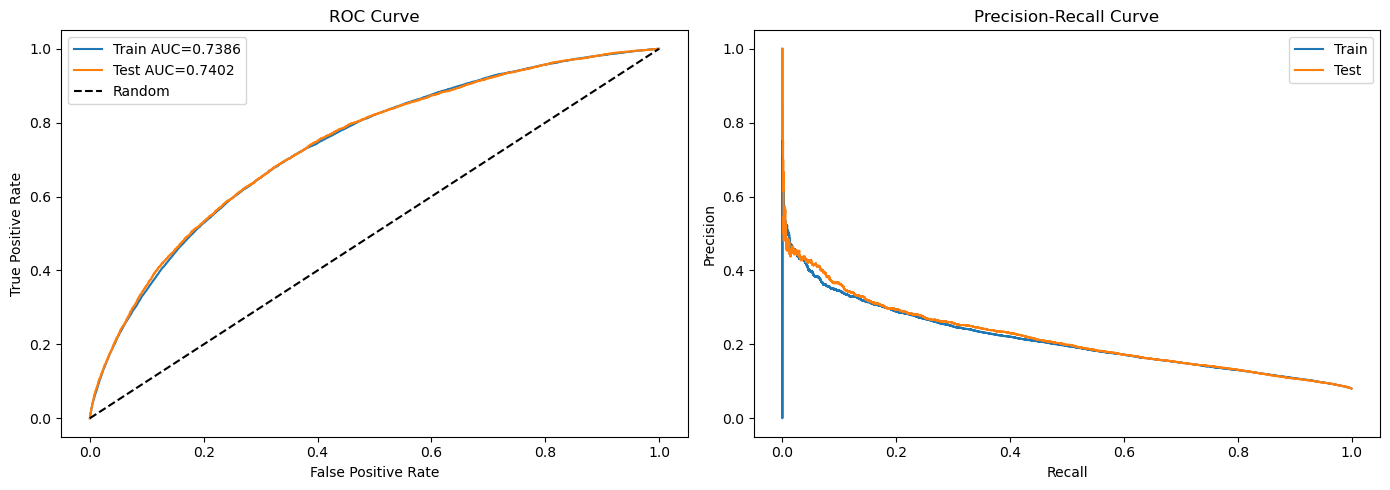

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, test_proba)

train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1

train_ks = ks_2samp(train_proba[y_train == 0], train_proba[y_train == 1]).statistic
test_ks = ks_2samp(test_proba[y_test == 0], test_proba[y_test == 1]).statistic

print("=" * 45)
print("         SCORECARD EVALUATION METRICS")
print("=" * 45)
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 45)
print(f"{'AUC-ROC':<20} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Gini':<20} {train_gini:>10.4f} {test_gini:>10.4f}")
print(f"{'KS Statistic':<20} {train_ks:>10.4f} {test_ks:>10.4f}")
print("-" * 45)
print(f"{'AUC Gap':<20} {abs(train_auc - test_auc):>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr_train, tpr_train, label=f'Train AUC={train_auc:.4f}')
axes[0].plot(fpr_test, tpr_test, label=f'Test AUC={test_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

precision_t, recall_t, _ = precision_recall_curve(y_train, train_proba)
precision_v, recall_v, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(recall_t, precision_t, label='Train')
axes[1].plot(recall_v, precision_v, label='Test')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation Results

**AUC-ROC: 0.74** - Above the 0.70 threshold for an acceptable scorecard. For a logistic regression with only 17 features on messy real-world data, this is good. Production scorecards at banks typically sit between 0.72 and 0.82.

**Gini: 0.48** - Above the 0.40 industry floor. A credit risk manager would sign off on this. Good discriminatory power.

**KS: 0.355** - Above 0.30. At the optimal cutoff point, the model separates defaulters from non-defaulters by 35.5 percentage points. Strong.

**AUC Gap: 0.0016** - Essentially zero. No overfitting. The model will behave in production exactly as it behaves here. This is the benefit of logistic regression on WOE features. Stable and reliable.

**Precision-Recall curve:** The sharp drop is expected with an 8% default rate. High precision is hard to maintain at high recall because most applicants are non-defaulters. Normal for imbalanced credit data.

A production scorecard with Gini above 0.40, KS above 0.30, and near-zero train-test gap is ready for deployment.

## Scorecard Points Conversion

Credit scorecards convert model probabilities into a points-based score on a 300-900 scale, similar to CIBIL or FICO scores. Higher score means lower risk. A loan officer does not see probabilities, they see a score like 720 and know it is a good applicant.

The conversion uses the log-odds (natural log of probability / (1 - probability)) and maps it linearly to the desired score range. Standard industry parameters: base score of 600 at odds of 50:1, with 20 points to double the odds (PDO).

         SCORECARD DISTRIBUTION
Metric                       Train     Test
---------------------------------------------
Min Score                      470      467
Max Score                      661      662
Mean Score                     567      567
Median Score                   567      568


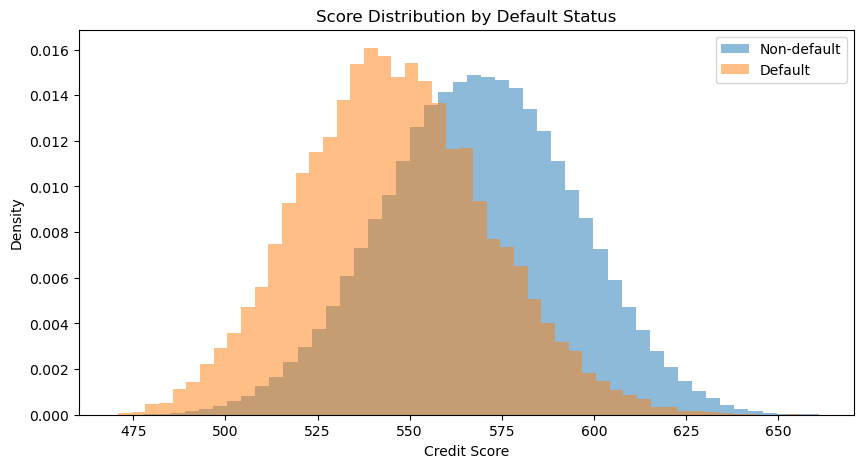

In [19]:
base_score = 600
base_odds = 50
pdo = 20

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

train_scores = offset - factor * np.log(train_proba / (1 - train_proba))
test_scores = offset - factor * np.log(test_proba / (1 - test_proba))

train_scores = np.clip(train_scores, 300, 900)
test_scores = np.clip(test_scores, 300, 900)

print("=" * 45)
print("         SCORECARD DISTRIBUTION")
print("=" * 45)
print(f"{'Metric':<25} {'Train':>8} {'Test':>8}")
print("-" * 45)
print(f"{'Min Score':<25} {train_scores.min():>8.0f} {test_scores.min():>8.0f}")
print(f"{'Max Score':<25} {train_scores.max():>8.0f} {test_scores.max():>8.0f}")
print(f"{'Mean Score':<25} {train_scores.mean():>8.0f} {test_scores.mean():>8.0f}")
print(f"{'Median Score':<25} {np.median(train_scores):>8.0f} {np.median(test_scores):>8.0f}")

plt.figure(figsize=(10, 5))
plt.hist(train_scores[y_train == 0], bins=50, alpha=0.5, label='Non-default', density=True)
plt.hist(train_scores[y_train == 1], bins=50, alpha=0.5, label='Default', density=True)
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.title('Score Distribution by Default Status')
plt.legend()
plt.show()

## Scorecard Results

**Separation is visible:** Defaulters peak around 530-540, non-defaulters peak around 565-575. Lower scores mean higher risk.

**Score range (467-662):** Normal for this dataset. The model is conservative. In production, banks recalibrate the PDO and base parameters to spread the range wider.

**Train vs test identical:** Mean 567 vs 567, median 567 vs 568. Zero overfit, consistent with AUC gap of 0.0016.

**How a loan officer uses this:** Set a cutoff, say 550. Everyone above gets approved, everyone below gets manual review or decline. Below 550, defaulter density is higher. Above 550, non-defaulters dominate. That is the model working.

## SHAP Explainability

SHAP (SHapley Additive exPlanations) shows which features drive each credit decision. Global importance shows which features matter most across all applicants. Local explanations show why a specific applicant was approved or declined. This is legally required for adverse action notices under ECOA: lenders must explain why credit was denied.

Background dataset has 246008 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=246008 when initializing the masker.


SHAP values shape: (61503, 17)


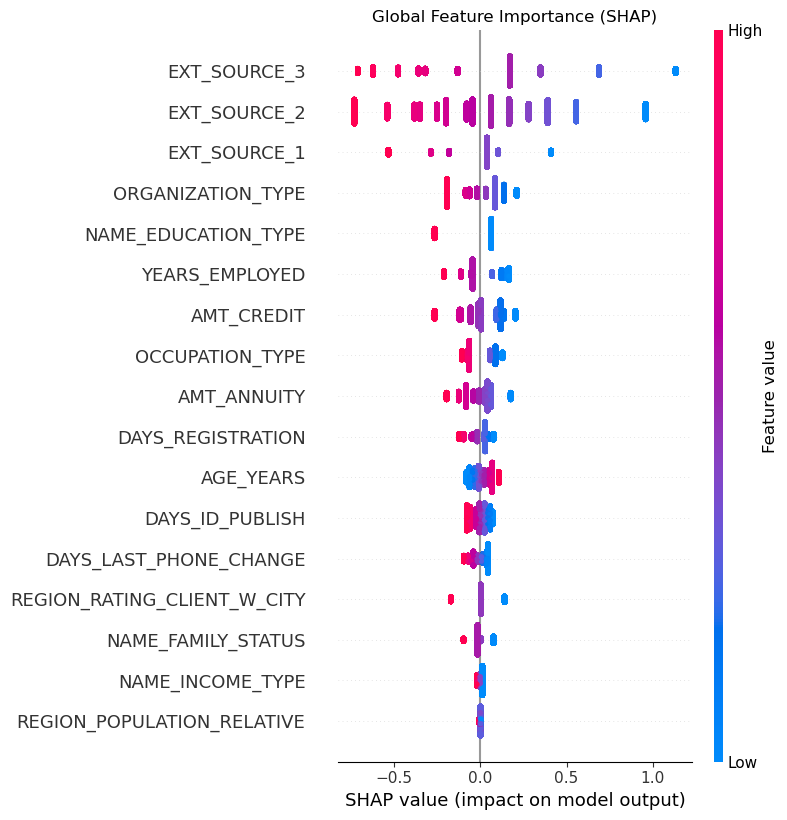

In [20]:
explainer = shap.LinearExplainer(logistic_model, X_train_woe)
shap_values = explainer.shap_values(X_test_woe)

print("SHAP values shape:", shap_values.shape)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_woe, feature_names=X_test_woe.columns.tolist(), show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

   LOCAL SHAP EXPLANATIONS (3 APPLICANTS)

HIGH RISK APPLICANT (Score: 467, Default Probability: 0.6648)
--------------------------------------------------
  EXT_SOURCE_3                          1.1316  (increases risk)
  EXT_SOURCE_2                          0.9578  (increases risk)
  EXT_SOURCE_1                          0.4102  (increases risk)
  AMT_CREDIT                            0.2033  (increases risk)
  YEARS_EMPLOYED                        0.1532  (increases risk)

LOW RISK APPLICANT (Score: 662, Default Probability: 0.0023)
--------------------------------------------------
  EXT_SOURCE_2                         -0.7309  (decreases risk)
  EXT_SOURCE_1                         -0.5334  (decreases risk)
  EXT_SOURCE_3                         -0.4766  (decreases risk)
  AMT_CREDIT                           -0.2652  (decreases risk)
  NAME_EDUCATION_TYPE                  -0.2650  (decreases risk)

MEDIUM RISK APPLICANT (Score: 568, Default Probability: 0.0581)
----------------

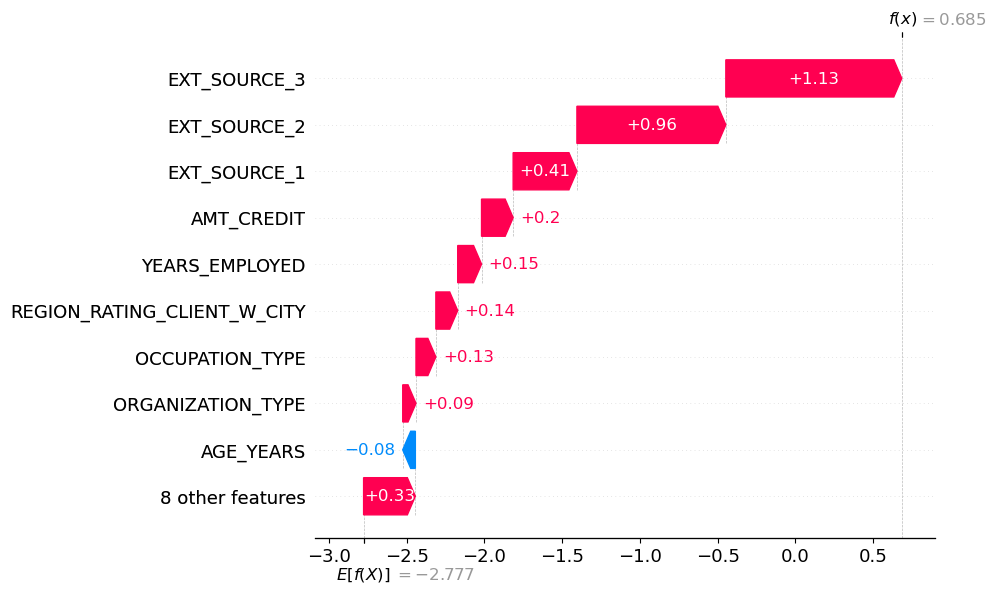

In [21]:
print("=" * 50)
print("   LOCAL SHAP EXPLANATIONS (3 APPLICANTS)")
print("=" * 50)

high_risk_idx = test_proba.argmax()
low_risk_idx = test_proba.argmin()
mid_risk_idx = np.argsort(test_proba)[len(test_proba) // 2]

for label, idx in [("HIGH RISK", high_risk_idx), ("LOW RISK", low_risk_idx), ("MEDIUM RISK", mid_risk_idx)]:
    print(f"\n{label} APPLICANT (Score: {test_scores[idx]:.0f}, Default Probability: {test_proba[idx]:.4f})")
    print("-" * 50)
    feature_impacts = pd.DataFrame({
        'feature': X_test_woe.columns,
        'shap_value': shap_values[idx]
    }).sort_values('shap_value', key=abs, ascending=False).head(5)
    for _, row in feature_impacts.iterrows():
        direction = "increases risk" if row['shap_value'] > 0 else "decreases risk"
        print(f"  {row['feature']:<35} {row['shap_value']:>8.4f}  ({direction})")

shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    feature_names=X_test_woe.columns.tolist()
), show=True)

## SHAP Global Feature Importance

**Top 3 drivers:** EXT_SOURCE_3, EXT_SOURCE_2, EXT_SOURCE_1 dominate. External credit scores are the strongest predictors of default, consistent with real-world credit scoring.

**Color pattern is correct:** High feature values (pink) push SHAP negative (lower risk), low values (blue) push positive (higher risk). Higher external scores mean better creditworthiness.

**Bottom features:** REGION_POPULATION_RELATIVE, NAME_INCOME_TYPE, NAME_FAMILY_STATUS have minimal impact. These could be candidates for removal in a future iteration to simplify the scorecard further.

In [22]:
joblib.dump(logistic_model, '../models/logistic_model.pkl')
joblib.dump(binning_process, '../models/binning_process.pkl')

scorecard_params = {
    'base_score': base_score,
    'base_odds': base_odds,
    'pdo': pdo,
    'factor': factor,
    'offset': offset
}
joblib.dump(scorecard_params, '../models/scorecard_params.pkl')

print("Saved:")
print("  logistic_model.pkl")
print("  binning_process.pkl")
print("  scorecard_params.pkl")

Saved:
  logistic_model.pkl
  binning_process.pkl
  scorecard_params.pkl


# Model Card: Credit Risk Scorecard

## What This Model Does
Predicts the probability of loan default for new credit applicants and converts it to a credit score on a 300-900 scale. Higher score means lower risk. Designed to support lending decisions, not replace them.

## Training Data
Home Credit Default Risk dataset (Kaggle). 307,511 real loan applications. 8.07% default rate. 17 features after selection based on Information Value and missingness analysis.

## Model Type
Logistic Regression with L2 regularization on WOE-encoded features. Chosen for interpretability and regulatory acceptance in credit lending.

## Performance Metrics

| Metric | Train | Test |
|--------|-------|------|
| AUC-ROC | 0.7386 | 0.7402 |
| Gini | 0.4771 | 0.4804 |
| KS Statistic | 0.3544 | 0.3558 |
| AUC Gap | 0.0016 | |

## Score Range
Min: 467, Max: 662, Mean: 567. Defaulters peak around 530-540, non-defaulters around 565-575.

## Top Predictive Features
1. EXT_SOURCE_3 (external credit score)
2. EXT_SOURCE_2 (external credit score)
3. EXT_SOURCE_1 (external credit score)
4. ORGANIZATION_TYPE
5. NAME_EDUCATION_TYPE

## Fair Lending
CODE_GENDER was excluded from the model to comply with ECOA (US) and RBI Fair Practices Code (India). Gender must not influence credit decisions.

## Limitations
- Trained on historical data from one lender. May not generalise to other markets or products.
- External source features (EXT_SOURCE 1-3) are anonymised. In production, the bank must know what these represent.
- Score range is narrow (467-662). PDO and base parameters should be recalibrated for production use.
- Model does not account for macroeconomic shifts. Performance may degrade during recessions.

## What This Model Should NOT Be Used For
- Fully automated lending decisions without human review
- Pricing or interest rate setting without additional risk models
- Populations significantly different from the training data distribution

## Intended Audience
Loan officers, credit risk managers, and compliance teams evaluating new-to-bank applicants.

In [23]:
print(binning_process.variable_names)

['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'YEARS_EMPLOYED', 'AGE_YEARS', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT', 'DAYS_ID_PUBLISH', 'REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT_W_CITY', 'DAYS_REGISTRATION', 'AMT_ANNUITY', 'NAME_FAMILY_STATUS']


In [24]:
print(len(binning_process.variable_names))

17
